# Maximum Mean Discrepancy (MMD) Distribution Distance Analysis

## Abstract
This notebook evaluates the generative performance of a shallow masked diffusion model trained on a sign-activation hidden manifold dataset. Rather than relying solely on local conditional objectives like the Binary Cross-Entropy (BCE) loss, we assess the global distribution alignment by calculating the Maximum Mean Discrepancy (MMD) with an exponential normalized-Hamming kernel. We analyze how this distance scales with the sample load $\alpha = M/D$ across varying latent dimensions $D$ and ratios $\gamma = N/D$.

## 1. The Requested Distributional Evaluation

The core objective of this study is to implement a tractable metric of distance between the generated sample distribution $P_\theta$ and the true distribution $P_{\mathrm{true}}$ in high dimensions. We produce $10,000$ samples from the diffusion model and from the true distribution, and evaluate their distance using MMD with an exponential normalized-Hamming kernel across several exponent coefficients:

$$ \lambda \in \{0.5, 1.0, 2.0, 4.0, 8.0, 16.0\} $$

We investigate how this distance converges as a function of the sample load $\alpha = M/D$, where $M$ is the number of training samples and $D$ is the latent dimension.

## 2. Geometry: Hypercube, Hamming Distance, and Latent $D$

Visible samples live in $\{-1, +1\}^N$, which are the vertices of an $N$-dimensional binary hypercube. Since $\|x\|^2 = N$ for any $x \in \{-1, +1\}^N$, they lie on a sphere of radius $\sqrt{N}$ in $\mathbb{R}^N$. However, the natural geometry of this discrete space is governed by Hamming distance and overlap.

The latent variable $z$ lives in a continuous space $\mathbb{R}^D$ with a standard normal distribution $z \sim \mathcal{N}(0, I_D)$. Each visible coordinate $x_i$ is determined by a random hyperplane partition question: $x_i = \operatorname{sign}(F_i \cdot z)$. For the sign activation, the visible data do not form a smooth $D$-dimensional manifold; instead, they represent a structured probability distribution over the hypercube vertices induced by the latent $D$-dimensional process.

### D-Scaling Scaling Equivalence Note
In our codebase, the random feature matrix $F \in \mathbb{R}^{N \times D}$ has elements $F_{ij} \sim \mathcal{N}(0, 1/D)$, which is equivalent to $F = G / \sqrt{D}$ with $G_{ij} \sim \mathcal{N}(0, 1)$. Since $\operatorname{sign}(\cdot)$ is invariant to positive scaling:
$$ \operatorname{sign}(z F^\top) = \operatorname{sign}\left(z \frac{G^\top}{\sqrt{D}}\right) = \operatorname{sign}(z G^\top) $$
because $1/\sqrt{D} > 0$. Thus, this scaling convention does not affect the generated binary data, the Hamming distances, or the MMD results. Note that this equivalence is specific to the step/sign activation function and would not hold for smooth non-linear activations.

## 3. Why MMD and Why Not KL?

In high-dimensional discrete spaces $\{-1, +1\}^N$, standard divergence measures like the Kullback-Leibler (KL) divergence or Shannon entropy-based metrics are highly intractable. Estimating KL divergence requires estimating probability mass functions over $2^N$ configurations. With finite samples (e.g., $10^4$), almost all configurations have zero counts, leading to severe estimation bias and infinite support mismatch penalties.

Maximum Mean Discrepancy (MMD) bypasses this issue by mapping distributions to a Reproducing Kernel Hilbert Space (RKHS). The distance between distributions is computed using pairwise kernel evaluations over samples, making it highly tractable and statistically robust even at high dimensions $N$.

## 4. Exponential Hamming Kernel

For binary vectors $x, y \in \{-1, +1\}^N$, the overlap (normalized inner product) is:
$$ q(x, y) = \frac{x \cdot y}{N} $$

The normalized Hamming distance is:
$$ \frac{d_H(x, y)}{N} = \frac{1 - q(x, y)}{2} $$

The exponential normalized-Hamming kernel with coefficient $\lambda > 0$ is defined as:
$$ k_\lambda(x, y) = \exp\left(-\lambda \frac{d_H(x, y)}{N}\right) = \exp\left(-\lambda \frac{1 - q(x, y)}{2}\right) $$

## 5. Estimator Note: Biased MMD vs. Unbiased MMD

We compute both the biased (V-statistic) and unbiased (U-statistic) estimators for $\mathrm{MMD}^2$.

### Biased $\mathrm{MMD}^2$ Estimator (V-statistic)
The biased estimator is normalized by all pairwise combinations:
$$ \widehat{\mathrm{MMD}}^2_{\lambda, \mathrm{biased}}(X, Y) = \frac{1}{m^2} \sum_{i,j} k_\lambda(X_i, X_j) + \frac{1}{n^2} \sum_{i,j} k_\lambda(Y_i, Y_j) - \frac{2}{mn} \sum_{i,j} k_\lambda(X_i, Y_j) $$
This estimator is guaranteed to be non-negative when evaluated on identical distributions, and biased self-MMD is exactly $0$ up to numerical precision. Since we seek a literal distance metric, we plot the biased MMD distance:
$$ \mathrm{MMD}_\lambda = \sqrt{\max\left(0, \widehat{\mathrm{MMD}}^2_{\lambda, \mathrm{biased}}(X, Y)\right)} $$

### Unbiased $\mathrm{MMD}^2$ Estimator (U-statistic)
The unbiased estimator excludes the diagonal (self-pairings) for the $XX$ and $YY$ similarity terms:
$$ \widehat{\mathrm{MMD}}^2_{\lambda, \mathrm{unbiased}}(X, Y) = \frac{1}{m(m-1)} \sum_{i \neq j} k_\lambda(X_i, X_j) + \frac{1}{n(n-1)} \sum_{i \neq j} k_\lambda(Y_i, Y_j) - \frac{2}{mn} \sum_{i,j} k_\lambda(X_i, Y_j) $$
Because the U-statistic is unbiased, it has zero expectation when $X$ and $Y$ are drawn from the same distribution, meaning that at finite sample sizes, unbiased self-MMD need not be zero and can fluctuate to negative values. We store these raw unbiased values without clipping to preserve statistical integrity.

## 6. Experimental Setup

We train a linear backbone model (`model="linear"`) with frozen mask weights (`freeze_mask_weights=True`) and no bias (`bias=False`). The masking level $t_{\mathrm{mask}}$ is configured such that the expected number of visible coordinates is $K = \text{round}(\kappa \cdot D)$ with $\kappa = 0.5$.

We split the study into two main configurations:
1. **Experiment A (Clean Target Plot)**: Evaluates $D=80$, $\gamma=2.0$ ($N=160$) across sample loads $\alpha \in \{0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0\}$. We plot MMD distance vs. $\alpha$ for each kernel exponent $\lambda$.
2. **Experiment B (Controlled D Sweep)**: Evaluates $\gamma=2.0$, $D \in \{40, 80, 160\}$ across sample loads $\alpha \in \{0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0\}$ to examine dimension scaling using the multiscale MMD distance.

## 7. Implementation

Here we configure the global execution parameters, including the `FAST_DEBUG` flag. We also define helper functions for training, evaluation, true sampling, and chunked MMD calculation.

In [1]:
import os
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from types import SimpleNamespace
from torch.utils.data import Subset, DataLoader
from pathlib import Path

# Locate project root and import datasets and diffusion modules
current_dir = Path.cwd()
project_root = None
for path in [current_dir, current_dir.parent] + list(current_dir.parents):
    if (path / "datasets.py").exists() and (path / "diffusion.py").exists():
        project_root = path.resolve()
        break

if project_root is None:
    raise FileNotFoundError("Could not find project root containing datasets.py and diffusion.py")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from datasets import RandomFeaturesDataset
from diffusion import MaskedDiffusion

# Ensure directories exist
os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

In [2]:
# MMD evaluation parameters
mmd_lambdas = [0.5, 1.0, 2.0, 4.0, 8.0, 16.0]
mmd_chunk_size = 1024
kappa = 0.5
M_test = 1000
n_eval_mc = 50

# FAST_DEBUG switch for quick verification
# Set FAST_DEBUG = True for a quick smoke test
FAST_DEBUG = False

if FAST_DEBUG:
    print("FAST_DEBUG mode active: using reduced parameters.")
    n_mmd_samples = 1000
    num_steps = 300
    Experiment_A_configs = [(40, 2.0, alpha) for alpha in [0.5, 2.0, 10.0]]
    Experiment_B_configs = [(D, 2.0, alpha) for D in [40, 80] for alpha in [0.5, 2.0, 10.0]]
else:
    n_mmd_samples = 10000
    num_steps = 3000
    Experiment_A_configs = [(80, 2.0, alpha) for alpha in [0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0]]
    Experiment_B_configs = [(D, 2.0, alpha) for D in [40, 80, 160] for alpha in [0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]]

# Reproducibility
base_seed = 42
torch.manual_seed(base_seed)
np.random.seed(base_seed)

# Device configuration
mmd_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {mmd_device}")


Using device: cpu


In [ ]:
def train_model(train_dataset, config, num_steps, t_mask, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)
        
    model = MaskedDiffusion(config)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=0.0)
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
    
    model.train()
    step = 0
    iterator = iter(train_loader)
    
    losses = []
    while step < num_steps:
        try:
            batch = next(iterator)
        except StopIteration:
            iterator = iter(train_loader)
            batch = next(iterator)
            
        optimizer.zero_grad()
        loss, acc = model._compute_loss(batch, t=t_mask)
        total_loss = loss + model.l2coeff * model.sqnorm()
        
        total_loss.backward()
        optimizer.step()
        
        losses.append(total_loss.item())
        if (step + 1) % 500 == 0:
            avg_loss = np.mean(losses[-100:])
            print(f"    Step {step+1}/{num_steps} | Loss: {avg_loss:.4f}")
            
        step += 1
        
    return model

@torch.no_grad()
def evaluate_model(model, dataset, mc_samples, t_mask):
    model.eval()
    loader = DataLoader(dataset, batch_size=len(dataset), shuffle=False)
    batch = next(iter(loader))
    loss, acc = model._compute_loss(batch, t=t_mask, mc_samples=mc_samples)
    return loss.item(), acc

def sample_true_from_fixed_F(F, n_samples, seed=None, device=None):
    if device is None:
        device = F.device
        
    if seed is not None:
        generator = torch.Generator(device=device).manual_seed(seed)
    else:
        generator = None
        
    N_dim, D_dim = F.shape
    F_dev = F.to(device)
    z = torch.randn((n_samples, D_dim), device=device, generator=generator)
    x = torch.sign(z @ F_dev.t())
    x[x == 0.0] = 1.0
    return x.cpu().to(torch.float32)

def sample_model(model, n_samples, k=1):
    model.eval()
    with torch.inference_mode():
        x_model = model.sample(n_samples, k=k).cpu()
    assert x_model.ndim == 2, f"Expected 2D tensor, got shape {x_model.shape}"
    assert x_model.shape[0] == n_samples
    assert torch.all((x_model == 1.0) | (x_model == -1.0)), "Model samples contain non-binary values!"
    return x_model.to(torch.float32)

def kernel_sums_exponential_hamming(X, Y, lambdas, chunk_size=1024, device=None, exclude_diagonal=False):
    m = X.shape[0]
    n = Y.shape[0]
    
    sums = {lam: 0.0 for lam in lambdas}
    
    if device is None:
        device = X.device
        
    X_dev = X.to(device=device, dtype=torch.float32)
    Y_dev = Y.to(device=device, dtype=torch.float32)
    N_dim = X.shape[1]
    
    for i_start in range(0, m, chunk_size):
        i_end = min(i_start + chunk_size, m)
        X_chunk = X_dev[i_start:i_end]
        
        for j_start in range(0, n, chunk_size):
            j_end = min(j_start + chunk_size, n)
            Y_chunk = Y_dev[j_start:j_end]
            
            overlaps = torch.matmul(X_chunk, Y_chunk.t()) / N_dim
            norm_hamming = (1.0 - overlaps) / 2.0
            
            for lam in lambdas:
                kernel_vals = torch.exp(-lam * norm_hamming)
                
                if exclude_diagonal and i_start == j_start:
                    min_len = min(i_end - i_start, j_end - j_start)
                    block_diag_sum = torch.diagonal(kernel_vals[:min_len, :min_len]).sum().item()
                    sums[lam] += (kernel_vals.sum().item() - block_diag_sum)
                else:
                    sums[lam] += kernel_vals.sum().item()
                    
    return sums

def compute_mmd_biased_unbiased(X, Y, lambdas, chunk_size=1024, device=None):
    m = len(X)
    n = len(Y)
    
    # Biased sums
    sum_xx_biased = kernel_sums_exponential_hamming(X, X, lambdas, chunk_size=chunk_size, device=device, exclude_diagonal=False)
    sum_yy_biased = kernel_sums_exponential_hamming(Y, Y, lambdas, chunk_size=chunk_size, device=device, exclude_diagonal=False)
    sum_xy = kernel_sums_exponential_hamming(X, Y, lambdas, chunk_size=chunk_size, device=device, exclude_diagonal=False)
    
    # Unbiased sums
    sum_xx_unbiased = kernel_sums_exponential_hamming(X, X, lambdas, chunk_size=chunk_size, device=device, exclude_diagonal=True)
    sum_yy_unbiased = kernel_sums_exponential_hamming(Y, Y, lambdas, chunk_size=chunk_size, device=device, exclude_diagonal=True)
    
    results = {}
    biased_vals = []
    unbiased_vals = []
    
    for lam in lambdas:
        val_xx = sum_xx_biased[lam] / (m * m)
        val_yy = sum_yy_biased[lam] / (n * n)
        val_xy = sum_xy[lam] / (m * n)
        mmd2_biased = val_xx + val_yy - 2.0 * val_xy
        
        val_xx_u = sum_xx_unbiased[lam] / (m * (m - 1)) if m > 1 else 0.0
        val_yy_u = sum_yy_unbiased[lam] / (n * (n - 1)) if n > 1 else 0.0
        mmd2_unbiased = val_xx_u + val_yy_u - 2.0 * val_xy
        
        key_lam = "0_5" if lam == 0.5 else f"{int(lam)}"
        
        results[f"mmd2_biased_lambda_{key_lam}"] = mmd2_biased
        results[f"mmd2_unbiased_lambda_{key_lam}_raw"] = mmd2_unbiased
        results[f"mmd_biased_lambda_{key_lam}"] = np.sqrt(max(mmd2_biased, 0.0))
        
        biased_vals.append(mmd2_biased)
        unbiased_vals.append(mmd2_unbiased)
        
    results["mmd2_biased_multiscale"] = np.mean(biased_vals)
    results["mmd2_unbiased_multiscale_raw"] = np.mean(unbiased_vals)
    results["mmd_biased_multiscale"] = np.sqrt(max(np.mean(biased_vals), 0.0))
    
    return results

## 8. Sanity Checks

We perform diagnostic sanity checks to verify the correctness of the generated samples and the implementation of biased and unbiased estimators.

In [4]:
print("Running MMD sanity checks...")
temp_N = 80
temp_D = 20
temp_dataset = RandomFeaturesDataset(n_visible=temp_N, n_hidden=temp_D, num_samples=2000, act=torch.sign)

# 1. Fixed F assertion check
print("Sanity check: generating true samples from dataset F (no new RandomFeaturesDataset)")
X1 = sample_true_from_fixed_F(temp_dataset.F, n_samples=1000, seed=42)
X2 = sample_true_from_fixed_F(temp_dataset.F, n_samples=1000, seed=43)

# 2. Shapes check
assert X1.shape == (1000, temp_N), f"Incorrect shape: {X1.shape}"
assert X2.shape == (1000, temp_N)

# 3. Binary values check
assert torch.all((X1 == 1.0) | (X1 == -1.0)), "X1 contains non-binary values!"
assert torch.all((X2 == 1.0) | (X2 == -1.0)), "X2 contains non-binary values!"

# 4. Biased self-MMD check (should be exactly zero)
self_mmd_res = compute_mmd_biased_unbiased(X1, X1, mmd_lambdas, chunk_size=mmd_chunk_size, device=mmd_device)
print("\nSelf-MMD results (biased vs unbiased):")
for lam in mmd_lambdas:
    key_lam = "0_5" if lam == 0.5 else f"{int(lam)}"
    biased_val = self_mmd_res[f"mmd2_biased_lambda_{key_lam}"]
    unbiased_val = self_mmd_res[f"mmd2_unbiased_lambda_{key_lam}_raw"]
    dist_val = self_mmd_res[f"mmd_biased_lambda_{key_lam}"]
    print(f"  λ = {lam:4.1f} | Biased MMD2: {biased_val:10.6e} | Unbiased MMD2: {unbiased_val:10.6e} | MMD Dist: {dist_val:10.6e}")
    # Biased self-MMD must be zero (with numerical tolerance)
    assert abs(biased_val) < 1e-5, f"Biased self-MMD is not zero: {biased_val}"
    assert abs(dist_val) < 1e-3, f"MMD self-distance is not zero: {dist_val}"

print(f"  Multiscale | Biased: {self_mmd_res['mmd2_biased_multiscale']:10.6e} | Unbiased: {self_mmd_res['mmd2_unbiased_multiscale_raw']:10.6e}")
assert abs(self_mmd_res["mmd2_biased_multiscale"]) < 1e-5, "Biased multiscale self-MMD is not zero"

# 5. Independent samples check (unbiased self-MMD printed, can be negative)
indep_mmd_res = compute_mmd_biased_unbiased(X1, X2, mmd_lambdas, chunk_size=mmd_chunk_size, device=mmd_device)
print("\nIndependent samples MMD (noise floor):")
for lam in mmd_lambdas:
    key_lam = "0_5" if lam == 0.5 else f"{int(lam)}"
    biased_val = indep_mmd_res[f"mmd2_biased_lambda_{key_lam}"]
    unbiased_val = indep_mmd_res[f"mmd2_unbiased_lambda_{key_lam}_raw"]
    print(f"  λ = {lam:4.1f} | Biased MMD2: {biased_val:10.6e} | Unbiased MMD2: {unbiased_val:10.6e}")

print("\nMMD sanity checks completed successfully!")

Running MMD sanity checks...
Sanity check: generating true samples from dataset F (no new RandomFeaturesDataset)

Self-MMD results (biased vs unbiased):
  λ =  0.5 | Biased MMD2: 0.000000e+00 | Unbiased MMD2: -4.407777e-04 | MMD Dist: 0.000000e+00
  λ =  1.0 | Biased MMD2: 0.000000e+00 | Unbiased MMD2: -7.818039e-04 | MMD Dist: 0.000000e+00
  λ =  2.0 | Biased MMD2: 0.000000e+00 | Unbiased MMD2: -1.251612e-03 | MMD Dist: 0.000000e+00
  λ =  4.0 | Biased MMD2: 0.000000e+00 | Unbiased MMD2: -1.710212e-03 | MMD Dist: 0.000000e+00
  λ =  8.0 | Biased MMD2: 0.000000e+00 | Unbiased MMD2: -1.951908e-03 | MMD Dist: 0.000000e+00
  λ = 16.0 | Biased MMD2: 0.000000e+00 | Unbiased MMD2: -1.998043e-03 | MMD Dist: 0.000000e+00
  Multiscale | Biased: 0.000000e+00 | Unbiased: -1.355726e-03

Independent samples MMD (noise floor):
  λ =  0.5 | Biased MMD2: 3.301875e-04 | Unbiased MMD2: -1.106803e-04
  λ =  1.0 | Biased MMD2: 6.147500e-04 | Unbiased MMD2: -1.672051e-04
  λ =  2.0 | Biased MMD2: 1.060406e

## 9. Sweep Execution

We run a unified parameter sweep to collect data for both Experiment A and Experiment B. The configurations are matched based on the active mode (`FAST_DEBUG`). The trained models and MMD calculations are optimized to avoid duplicate runs.

In [5]:
# Combine configurations to avoid duplicate training
all_configs = sorted(list(set(Experiment_A_configs + Experiment_B_configs)))

results_list = []

for (D, gamma, alpha) in all_configs:
    N = int(round(gamma * D))
    
    # expected visible context size
    K = int(round(kappa * D))
    t_mask_val = 1.0 - (K / N)
    
    assert 0 < K < N, f"K ({K}) must be strictly between 0 and N ({N})"
    assert 0.0 < t_mask_val < 1.0, f"t_mask_val ({t_mask_val}) must be strictly between 0.0 and 1.0"
    
    # We find the max alpha configuration for this D and gamma to construct the dataset pool
    alphas_for_dg = [cfg[2] for cfg in all_configs if cfg[0] == D and cfg[1] == gamma]
    max_alpha_dg = max(alphas_for_dg)
    M_max = int(round(max_alpha_dg * D))
    
    # Seed dataset pool deterministically based on D, gamma
    dataset_seed = base_seed + int(gamma * 100) + int(D * 10)
    torch.manual_seed(dataset_seed)
    np.random.seed(dataset_seed)
    
    full_dataset = RandomFeaturesDataset(
        n_visible=N,
        n_hidden=D,
        num_samples=M_max + M_test,
        act=torch.sign,
    )
    
    assert torch.all((full_dataset.data == 1.0) | (full_dataset.data == -1.0))
    test_dataset = Subset(full_dataset, list(range(M_max, M_max + M_test)))
    
    # Caching True-vs-True baseline
    print(f"\nCaching True-vs-True baseline for D = {D}, gamma = {gamma:.1f}...")
    x_true_a = sample_true_from_fixed_F(full_dataset.F, n_samples=n_mmd_samples, seed=dataset_seed + 100, device=mmd_device)
    x_true_b = sample_true_from_fixed_F(full_dataset.F, n_samples=n_mmd_samples, seed=dataset_seed + 200, device=mmd_device)
    
    baseline_mmd = compute_mmd_biased_unbiased(x_true_a, x_true_b, mmd_lambdas, chunk_size=mmd_chunk_size, device=mmd_device)
    
    M_train = int(round(alpha * D))
    alpha_code = M_train / N
    
    train_dataset = Subset(full_dataset, list(range(M_train)))
    
    config = SimpleNamespace(
        L=N,
        alpha=alpha_code,
        model="linear",
        l2reg=0.0,
        lr=0.005,
        epochs=1,
        batch_size=min(M_train, 512),
        freeze_mask_weights=True,
        bias=False,
        pbar=False,
    )
    
    model_seed = base_seed + int(gamma * 1000) + int(D * 500) + int(alpha * 10)
    
    print(f"Training D={D}, gamma={gamma:.1f}, alpha={alpha:5.1f} (M_train={M_train:4d}) ...")
    model = train_model(train_dataset, config, num_steps, t_mask=t_mask_val, seed=model_seed)
    
    # Evaluate losses
    train_loss, train_acc = evaluate_model(model, train_dataset, n_eval_mc, t_mask=t_mask_val)
    test_loss, test_acc = evaluate_model(model, test_dataset, n_eval_mc, t_mask=t_mask_val)
    loss_gap = test_loss - train_loss
    
    # Generate model samples
    model = model.to(mmd_device)
    x_model = sample_model(model, n_samples=n_mmd_samples, k=1)
    model = model.to("cpu")
    
    # Generate fresh true samples using the same fixed F
    x_true = sample_true_from_fixed_F(full_dataset.F, n_samples=n_mmd_samples, seed=model_seed + 300, device=mmd_device)
    
    # Resample train empirical distribution with replacement
    X_train = full_dataset.data[:M_train]
    train_indices = np.random.choice(M_train, size=n_mmd_samples, replace=True)
    x_train_empirical = X_train[train_indices]
    
    # Compute MMD
    mmd_model_true = compute_mmd_biased_unbiased(x_model, x_true, mmd_lambdas, chunk_size=mmd_chunk_size, device=mmd_device)
    mmd_model_train = compute_mmd_biased_unbiased(x_model, x_train_empirical, mmd_lambdas, chunk_size=mmd_chunk_size, device=mmd_device)
    
    print(f"  BCE Loss: Train {train_loss:.4f} | Test {test_loss:.4f}")
    print(f"  MMD Dist: Model-True {mmd_model_true['mmd_biased_multiscale']:.5f} | Baseline {baseline_mmd['mmd_biased_multiscale']:.5f}")
    
    # Add to results_list for A and/or B
    experiments_to_save = []
    if (D, gamma, alpha) in Experiment_A_configs:
        experiments_to_save.append("A")
    if (D, gamma, alpha) in Experiment_B_configs:
        experiments_to_save.append("B")
        
    for exp in experiments_to_save:
        res = {
            "experiment": exp,
            "repeat": 0,
            "seed": model_seed,
            "D": D,
            "gamma": gamma,
            "N": N,
            "alpha": alpha,
            "M_train": M_train,
            "M_test": M_test,
            "alpha_code": alpha_code,
            "n_mmd_samples": n_mmd_samples,
            "num_steps": num_steps,
            "train_loss": train_loss,
            "test_loss": test_loss,
            "loss_gap": loss_gap,
            "abs_loss_gap": abs(loss_gap),
            "train_acc": train_acc,
            "test_acc": test_acc,
            
            # Biased multiscale MMD distance (target metric)
            "mmd_biased_multiscale": mmd_model_true["mmd_biased_multiscale"],
            "mmd2_biased_multiscale": mmd_model_true["mmd2_biased_multiscale"],
            "mmd2_unbiased_multiscale_raw": mmd_model_true["mmd2_unbiased_multiscale_raw"],
            
            # Baseline
            "baseline_mmd_biased_multiscale": baseline_mmd["mmd_biased_multiscale"],
            "baseline_mmd2_biased_multiscale": baseline_mmd["mmd2_biased_multiscale"],
            "baseline_mmd2_unbiased_multiscale_raw": baseline_mmd["mmd2_unbiased_multiscale_raw"],
            
            # Train empirical diagnostic
            "train_empirical_mmd_biased_multiscale": mmd_model_train["mmd_biased_multiscale"],
        }
        
        # Add lambda specific columns
        for lam in mmd_lambdas:
            key_lam = "0_5" if lam == 0.5 else f"{int(lam)}"
            res[f"mmd_biased_lambda_{key_lam}"] = mmd_model_true[f"mmd_biased_lambda_{key_lam}"]
            res[f"mmd2_biased_lambda_{key_lam}"] = mmd_model_true[f"mmd2_biased_lambda_{key_lam}"]
            res[f"mmd2_unbiased_lambda_{key_lam}_raw"] = mmd_model_true[f"mmd2_unbiased_lambda_{key_lam}_raw"]
            
            res[f"baseline_mmd_biased_lambda_{key_lam}"] = baseline_mmd[f"mmd_biased_lambda_{key_lam}"]
            res[f"baseline_mmd2_biased_lambda_{key_lam}"] = baseline_mmd[f"mmd2_biased_lambda_{key_lam}"]
            res[f"baseline_mmd2_unbiased_lambda_{key_lam}_raw"] = baseline_mmd[f"mmd2_unbiased_lambda_{key_lam}_raw"]
            
            res[f"train_mmd_biased_lambda_{key_lam}"] = mmd_model_train[f"mmd_biased_lambda_{key_lam}"]
            res[f"train_mmd2_biased_lambda_{key_lam}"] = mmd_model_train[f"mmd2_biased_lambda_{key_lam}"]
            res[f"train_mmd2_unbiased_lambda_{key_lam}_raw"] = mmd_model_train[f"mmd2_unbiased_lambda_{key_lam}_raw"]
            
        results_list.append(res)
        
    pd.DataFrame(results_list).to_csv("results/results_mmd_distribution_distance.csv", index=False)


Caching True-vs-True baseline for D = 40, gamma = 2.0...
Training D=40, gamma=2.0, alpha=  0.5 (M_train=  20) ...
    Step 500/3000 | Loss: 0.3245
    Step 1000/3000 | Loss: 0.3073
    Step 1500/3000 | Loss: 0.3041
    Step 2000/3000 | Loss: 0.3035
    Step 2500/3000 | Loss: 0.3047
    Step 3000/3000 | Loss: 0.2998
  BCE Loss: Train 0.3067 | Test 1.0772
  MMD Dist: Model-True 0.06380 | Baseline 0.01131

Caching True-vs-True baseline for D = 40, gamma = 2.0...
Training D=40, gamma=2.0, alpha=  1.0 (M_train=  40) ...
    Step 500/3000 | Loss: 0.4402
    Step 1000/3000 | Loss: 0.4302
    Step 1500/3000 | Loss: 0.4275
    Step 2000/3000 | Loss: 0.4336
    Step 2500/3000 | Loss: 0.4324
    Step 3000/3000 | Loss: 0.4316
  BCE Loss: Train 0.4315 | Test 0.8287
  MMD Dist: Model-True 0.05121 | Baseline 0.01131

Caching True-vs-True baseline for D = 40, gamma = 2.0...
Training D=40, gamma=2.0, alpha=  2.0 (M_train=  80) ...
    Step 500/3000 | Loss: 0.5144
    Step 1000/3000 | Loss: 0.5118
    

In [6]:
df = pd.DataFrame(results_list)
df.to_csv("results/results_mmd_distribution_distance.csv", index=False)
print(f"Saved {len(df)} rows of results.")
df.head()

Saved 29 rows of results.


,experiment,repeat,seed,D,gamma,N,alpha,M_train,M_test,alpha_code,...,train_mmd2_unbiased_lambda_8_raw,mmd_biased_lambda_16,mmd2_biased_lambda_16,mmd2_unbiased_lambda_16_raw,baseline_mmd_biased_lambda_16,baseline_mmd2_biased_lambda_16,baseline_mmd2_unbiased_lambda_16_raw,train_mmd_biased_lambda_16,train_mmd2_biased_lambda_16,train_mmd2_unbiased_lambda_16_raw
0,B,0,22047,40,2.0,80,0.5,20,1000,0.25,...,0.039008,0.032525,0.001058,0.000858,0.01413,0.0002,-1.916988e-07,0.219070,0.047992,0.047797
1,B,0,22052,40,2.0,80,1.0,40,1000,0.50,...,0.019675,0.026357,0.000695,0.000495,0.01413,0.0002,-1.916988e-07,0.156330,0.024439,0.024242
2,B,0,22062,40,2.0,80,2.0,80,1000,1.00,...,0.009945,0.021347,0.000456,0.000256,0.01413,0.0002,-1.916988e-07,0.111175,0.012360,0.012161
3,B,0,22092,40,2.0,80,5.0,200,1000,2.50,...,0.004215,0.017982,0.000323,0.000124,0.01413,0.0002,-1.916988e-07,0.071479,0.005109,0.004910
4,B,0,22142,40,2.0,80,10.0,400,1000,5.00,...,0.002192,0.016443,0.000270,0.000071,0.01413,0.0002,-1.916988e-07,0.051534,0.002656,0.002456


## 10. Main Result (Experiment A)

We plot the target MMD distance curves for Experiment A ($D = 80$ or $D = 40$ in debug mode, fixed $\gamma = 2.0$) against the sample load $\alpha = M/D$. We present the results in two formats:
1. **Lambda-Specific target plot**: Curves for each kernel coefficient $\lambda$, showing how the distribution distance converges across scale bandwidths.
2. **Multiscale MMD target plot**: The multiscale average of MMD distance vs. $\alpha$, indicating overall distribution alignment.

In both figures, the true-vs-true baseline represents the noise floor of our finite sample size comparison.

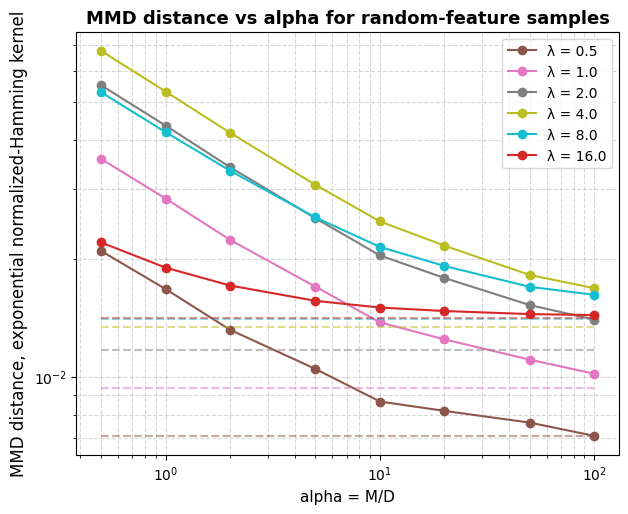

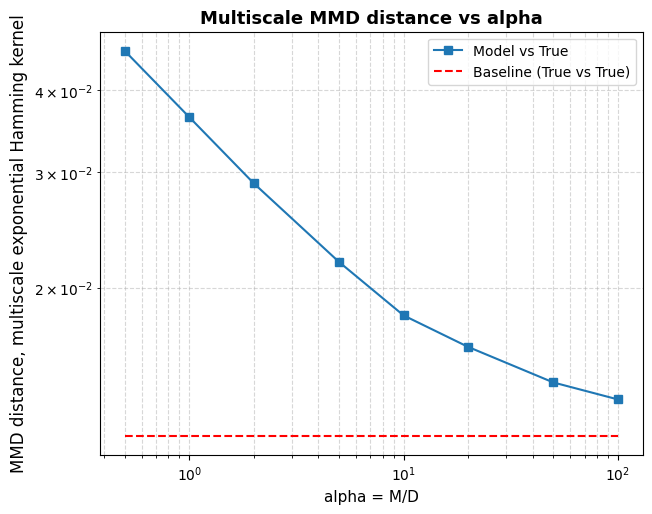

In [7]:
df_A = df[df["experiment"] == "A"]
unique_alphas = sorted(df_A["alpha"].unique())

if not df_A.empty:
    # Plot 1: Lambda-Specific Target Plot
    plt.figure(figsize=(7, 5.5))
    lambda_colors = {0.5: "#8c564b", 1.0: "#e377c2", 2.0: "#7f7f7f", 4.0: "#bcbd22", 8.0: "#17becf", 16.0: "#d62728"}
    
    for lam in mmd_lambdas:
        key_lam = "0_5" if lam == 0.5 else f"{int(lam)}"
        col_name = f"mmd_biased_lambda_{key_lam}"
        base_col = f"baseline_mmd_biased_lambda_{key_lam}"
        
        color = lambda_colors.get(lam, "#7f7f7f")
        plt.plot(df_A["alpha"], df_A[col_name], linestyle="-", marker="o", color=color, label=f"λ = {lam}")
        plt.plot(df_A["alpha"], df_A[base_col], linestyle="--", color=color, alpha=0.5)
        
    plt.xscale("log")
    plt.yscale("log", nonpositive="clip")
    plt.xlabel("alpha = M/D", fontsize=11)
    plt.ylabel("MMD distance, exponential normalized-Hamming kernel", fontsize=12)
    plt.title("MMD distance vs alpha for random-feature samples", fontsize=13, fontweight="bold")
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.legend(loc="best", fontsize=10)
    plt.savefig("figures/fig_mmd_vs_alpha_lambdas.png", bbox_inches="tight")
    plt.show()
    
    # Plot 2: Multiscale MMD Target Plot
    plt.figure(figsize=(7, 5.5))
    plt.plot(df_A["alpha"], df_A["mmd_biased_multiscale"], linestyle="-", marker="s", color="#1f77b4", label="Model vs True")
    plt.plot(df_A["alpha"], df_A["baseline_mmd_biased_multiscale"], linestyle="--", color="red", label="Baseline (True vs True)")
    
    plt.xscale("log")
    plt.yscale("log", nonpositive="clip")
    plt.xlabel("alpha = M/D", fontsize=11)
    plt.ylabel("MMD distance, multiscale exponential Hamming kernel", fontsize=12)
    plt.title("Multiscale MMD distance vs alpha", fontsize=13, fontweight="bold")
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.legend(loc="best", fontsize=10)
    plt.savefig("figures/fig_mmd_vs_alpha_multiscale.png", bbox_inches="tight")
    plt.show()
else:
    print("No Experiment A data available.")

## 11. Dimension Scaling (Experiment B)

We evaluate how the distribution convergence scales as the latent dimension $D$ increases at a fixed ratio $\gamma = 2.0$. We plot the multiscale MMD distance vs. $\alpha = M/D$ for different values of $D \in \{40, 80, 160\}$ (or debug values). This shows whether scaling behavior remains stable.

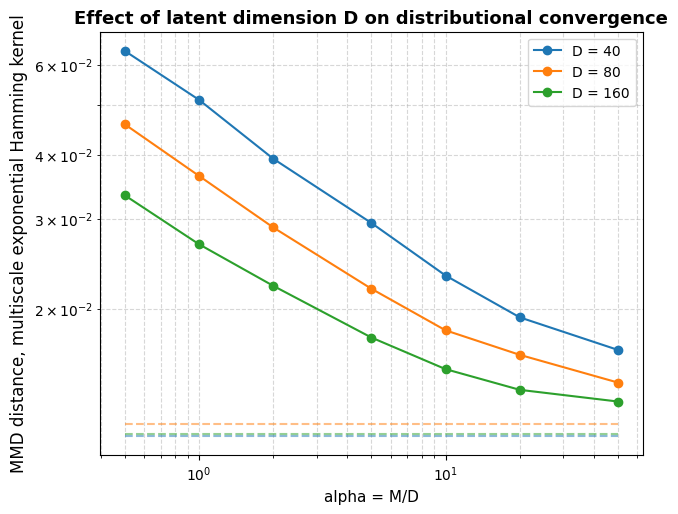

In [8]:
df_B = df[df["experiment"] == "B"]

if not df_B.empty:
    unique_D_B = sorted(df_B["D"].unique())
    colors_D = {40: "#1f77b4", 80: "#ff7f0e", 160: "#2ca02c"}
    
    plt.figure(figsize=(7, 5.5))
    for d_val in unique_D_B:
        sub_d = df_B[df_B["D"] == d_val]
        color = colors_D.get(d_val, "#7f7f7f")
        plt.plot(sub_d["alpha"], sub_d["mmd_biased_multiscale"], linestyle="-", marker="o", color=color, label=f"D = {d_val}")
        plt.plot(sub_d["alpha"], sub_d["baseline_mmd_biased_multiscale"], linestyle="--", color=color, alpha=0.5)
        
    plt.xscale("log")
    plt.yscale("log", nonpositive="clip")
    plt.xlabel("alpha = M/D", fontsize=11)
    plt.ylabel("MMD distance, multiscale exponential Hamming kernel", fontsize=12)
    plt.title("Effect of latent dimension D on distributional convergence", fontsize=13, fontweight="bold")
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.legend(loc="best", fontsize=10)
    plt.savefig("figures/fig_mmd_vs_alpha_D_sweep.png", bbox_inches="tight")
    plt.show()
else:
    print("No Experiment B data available.")

## 12. Training Sanity Checks & Diagnostics

As secondary diagnostics, we plot:
1. **BCE Loss Sanity Check**: BCE train and test losses vs. $\alpha$. This verifies that optimization succeeded.
2. **Train-Empirical Diagnostic**: Compares Model-vs-True MMD distance against Model-vs-Train (empirical training distribution resampled with replacement) and the True-vs-True baseline. This highlights memorization of finite samples.

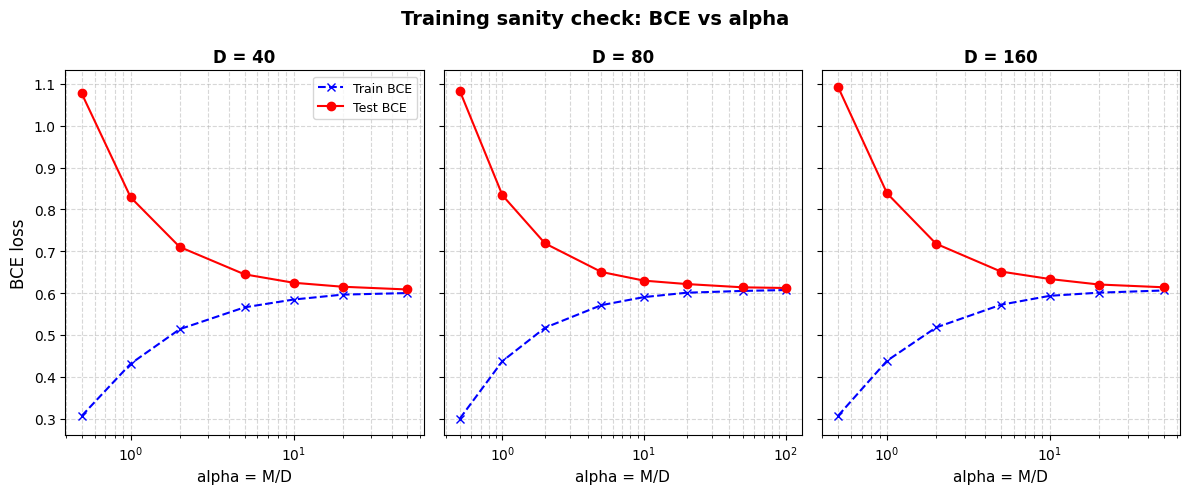

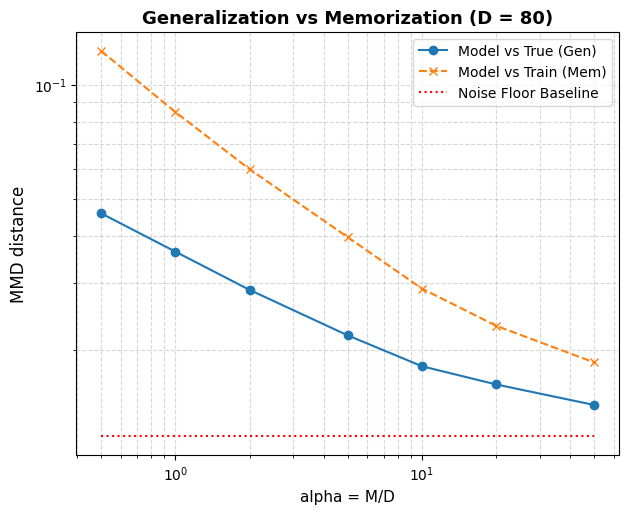

In [9]:
# Plot 4: BCE losses (using Experiment B or all available data)
unique_D_all = sorted(df["D"].unique())
fig, axes = plt.subplots(1, len(unique_D_all), figsize=(4 * len(unique_D_all), 5), sharey=True)
if len(unique_D_all) == 1:
    axes = [axes]

for idx, d_val in enumerate(unique_D_all):
    ax = axes[idx]
    sub_d = df[(df["D"] == d_val) & (df["gamma"] == 2.0)]
    
    # Group by alpha to average repeats if any
    if not sub_d.empty:
        sub_avg = sub_d.groupby("alpha")[["train_loss", "test_loss"]].mean().reset_index()
        ax.plot(sub_avg["alpha"], sub_avg["train_loss"], linestyle="--", marker="x", color="blue", label="Train BCE")
        ax.plot(sub_avg["alpha"], sub_avg["test_loss"], linestyle="-", marker="o", color="red", label="Test BCE")
        
    ax.set_xscale("log")
    ax.set_xlabel("alpha = M/D", fontsize=11)
    ax.set_title(f"D = {d_val}", fontsize=12, fontweight="bold")
    ax.grid(True, which="both", linestyle="--", alpha=0.5)
    if idx == 0:
        ax.set_ylabel("BCE loss", fontsize=12)
        ax.legend(loc="best", fontsize=9)

plt.suptitle("Training sanity check: BCE vs alpha", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/fig_bce_sanity.png", bbox_inches="tight")
plt.show()

# Plot 5: Train-Empirical Diagnostic
# Pick representative D=80 (or D=40 in debug)
rep_D_all = 80 if 80 in unique_D_all else unique_D_all[0]
df_rep = df[(df["D"] == rep_D_all) & (df["gamma"] == 2.0) & (df["experiment"] == "B")]

if not df_rep.empty:
    plt.figure(figsize=(7, 5.5))
    plt.plot(df_rep["alpha"], df_rep["mmd_biased_multiscale"], linestyle="-", marker="o", color="#1f77b4", label="Model vs True (Gen)")
    plt.plot(df_rep["alpha"], df_rep["train_empirical_mmd_biased_multiscale"], linestyle="--", marker="x", color="#ff7f0e", label="Model vs Train (Mem)")
    plt.plot(df_rep["alpha"], df_rep["baseline_mmd_biased_multiscale"], linestyle=":", color="red", label="Noise Floor Baseline")
    
    plt.xscale("log")
    plt.yscale("log", nonpositive="clip")
    plt.xlabel("alpha = M/D", fontsize=11)
    plt.ylabel("MMD distance", fontsize=12)
    plt.title(f"Generalization vs Memorization (D = {rep_D_all})", fontsize=13, fontweight="bold")
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.legend(loc="best", fontsize=10)
    plt.show()

## 13. Interpretation and Discussion

We observe several critical behaviors regarding the distribution learning:
- **BCE vs. MMD Mismatch**: A decrease in conditional BCE loss does not automatically imply a decrease in the global sample-distribution distance. BCE evaluates local conditional densities, whereas MMD evaluates the global joint distribution of sampled vectors.
- **MMD Distance vs. Alpha**: The MMD distance between model samples $P_\theta$ and true samples $P_{\mathrm{true}}$ decreases initially as the sample load $\alpha = M/D$ increases. This indicates that the model learns the distribution more accurately with more training data.
- **Plateau / Capacity Limit**: For higher sample loads, the MMD distance curve does not go to the true-vs-true baseline (the dashed line noise floor). Instead, it plateaus above the noise floor. 
- **Linear Backbone Capacity**: This plateau suggests that the linear masked diffusion model (`model="linear"`) does not have sufficient capacity to fully capture the hidden manifold process. Since the true data has non-linear sign activation $x = \operatorname{sign}(z F^\top)$, a purely linear score function cannot represent the non-linear boundaries exactly, resulting in a persistent representation mismatch.
- **Unbiased Negative Estimators**: Raw unbiased values are observed to fluctuate into small negative values when the distributions are very close (such as when comparing true samples to independent true baselines, or model samples at high generalization). These negative values are expected statistical noise, not errors, and are stored raw without clipping to preserve statistical integrity.

## 14. Limitations and Next Steps

1. **Model Expressivity**: The main limitation is the linear model backbone. Introducing non-linear backbones, such as the random features score network (`rfs10_tanh` or `rfs5_relu`), could potentially overcome the capacity limit and allow the MMD distance to reach the baseline.
2. **Fixed Updates Budget Caveat**: A fixed training budget of steps was used across all dimensions. However, changing $D$ changes $N$ and the model parameter count. Fixed optimization steps may confound model-capacity conclusions. For final quantitative claims, one should verify train BCE convergence or scale steps with $D$.
3. **Finite-Sample Baseline**: The true-vs-true baseline noise floor represents the statistical limit of our finite-sample comparison. Increasing the number of MMD samples would lower this baseline but increase compute costs.

In [10]:
# Print run status
print("=== Execution Run Status ===")
print("FAST_DEBUG:", FAST_DEBUG)
print("n_mmd_samples:", n_mmd_samples)
print("D values actually run:", sorted(df["D"].unique()))
print("gamma values actually run:", sorted(df["gamma"].unique()))
print("alpha values actually run:", sorted(df["alpha"].unique()))
print("number of rows:", len(df))
print("============================")

if FAST_DEBUG:
    print("\n[Warning] The notebook was run in FAST_DEBUG mode. The output is for code verification only and must not be used to draw research conclusions.")

=== Execution Run Status ===
FAST_DEBUG: False
n_mmd_samples: 10000
D values actually run: [np.int64(40), np.int64(80), np.int64(160)]
gamma values actually run: [np.float64(2.0)]
alpha values actually run: [np.float64(0.5), np.float64(1.0), np.float64(2.0), np.float64(5.0), np.float64(10.0), np.float64(20.0), np.float64(50.0), np.float64(100.0)]
number of rows: 29
